

## Introduction and problem statement for modeling 

"Can we predict whether a given day will be a high-revenue or low-revenue day, based on temporal features?"

## Dataset Description after pre-processing 
The dataset contains 9,540 café transactions recorded throughout the full year of 2023 (January 1 to December 31), spread across 20 columns with no missing values. It captures 8 menu items — Juice, Coffee, Salad, Cake, Sandwich, Smoothie, Cookie, and Tea — with Juice being the most frequently purchased. 

Each transaction records the quantity (1–5 units), price per unit (£1–£5), and total spent (£1–£25), with an average transaction value of £8.93 and an average daily revenue of £233.

Orders are split between two location types: Takeaway (70%) and In-store (30%). Payment is made via Digital Wallet (55%), Credit Card (23%), or Cash (23%). Transactions are distributed across all times of day — afternoon (40%), morning (32%), and evening (27%) — and cover both weekdays (71%) and weekends (29%).

Beyond the raw transactional fields, the dataset includes several pre-engineered features such as hour, month, quarter, day_of_week, time_of_day, and binary flags (is_weekend, is_cash, is_credit_card, is_digital_wallet, is_takeaway).


In [110]:
import pandas as pd

df = pd.read_csv('cafe.csv')

# Check the dataset period 

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

print(df['Transaction Date'].min())  # First date
print(df['Transaction Date'].max())  # Last date
print(df['Transaction Date'].dt.year.unique())  # Years present

2023-01-01 00:00:00
2023-12-31 00:00:00
[2023]


In [111]:
# Check what columns
print(df.columns.tolist())

['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Transaction Time', 'hour', 'year', 'month', 'day_of_week', 'is_weekend', 'quarter', 'time_of_day', 'is_cash', 'is_credit_card', 'is_digital_wallet', 'is_takeaway']


In [112]:
# Check which numerical and which text 

# Numerical columns
print("NUMERICAL COLUMNS:")
print(df.select_dtypes(include='number').columns.tolist())

# Text columns
print("\nTEXT COLUMNS:")
print(df.select_dtypes(include='object').columns.tolist())

NUMERICAL COLUMNS:
['Quantity', 'Price Per Unit', 'Total Spent', 'hour', 'year', 'month', 'day_of_week', 'is_weekend', 'quarter', 'is_cash', 'is_credit_card', 'is_digital_wallet', 'is_takeaway']

TEXT COLUMNS:
['Transaction ID', 'Item', 'Payment Method', 'Location', 'Transaction Time', 'time_of_day']


# Logistic regression  

To address the problem of predicting whether a given day is a high- or low-revenue day, a Logistic Regression model was selected as the baseline classification approach. 

The model estimates the probability that a given day belongs to the “high revenue” class based on temporal and lag-based features derived from historical data.

We chose to start with this model beacuse: 

- Logistic Regression allows clear interpretation of feature effects, making it suitable for understanding how temporal factors can influence revenue outcomes.
- Works as a strong baseline model against which more complex models can later be compared.
- The model produces probability estimates, enabling analysis of prediction confidence and decision thresholds.

## Training and Validation Strategy

A time-based train-test split was applied:

Training set: January–September 2023
Test set: October–December 2023

This approach preserves temporal ordering and avoids data leakage, ensuring that the model is evaluated on future, unseen data. However, it would be interesting to see how it performs against other test sets in cross validation folds. Additionally, all input features were standardized using StandardScaler to ensure consistent feature scaling and improve model convergence

## Results

The Logistic Regression model was evaluated on the test dataset (October–December 2023) to assess its ability to classify days as either high- or low-revenue.

The target variable was well balanced, with:

179 high-revenue days (50%)
179 low-revenue days (50%)

This confirms that the use of the median revenue (£230.75) as the threshold successfully avoided class imbalance, ensuring a fair evaluation of model performance. The model achieved an accuracy of 0.609 (60.9%), indicating that it correctly classified approximately 61% of days in the test set.

When the model predicts a low-revenue day, it is correct 62% of the time However, it only identifies 51% of all actual low-revenue days, meaning it misses nearly half of them. Regarding High revenue days, the model correctly identifies 70% of high-revenue days, with 40% of predicted high-revenue days are incorrect

The model demonstrates a slight tendency toward predicting high-revenue days more effectively than low-revenue days, therefore the model is better at capturing upward revenue patterns but struggles more with identifying low-demand periods.

The imbalance between recall scores implies that the model may misclassify low-revenue days as high-revenue days, which can lead the busienss to overestimate demand, potentially resulting in overstaffing or excess inventory. 

Median daily revenue: £230.75
Class distribution:
revenue_class
1    179
0    179
Name: count, dtype: int64

Accuracy: 0.609

Classification Report:
              precision    recall  f1-score   support

 Low revenue       0.62      0.51      0.56        45
High revenue       0.60      0.70      0.65        47

    accuracy                           0.61        92
   macro avg       0.61      0.61      0.60        92
weighted avg       0.61      0.61      0.60        92



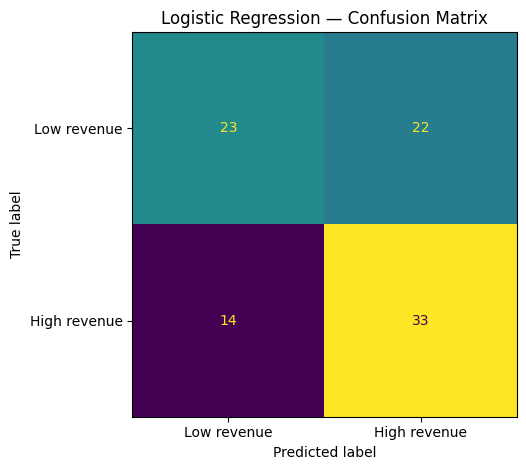

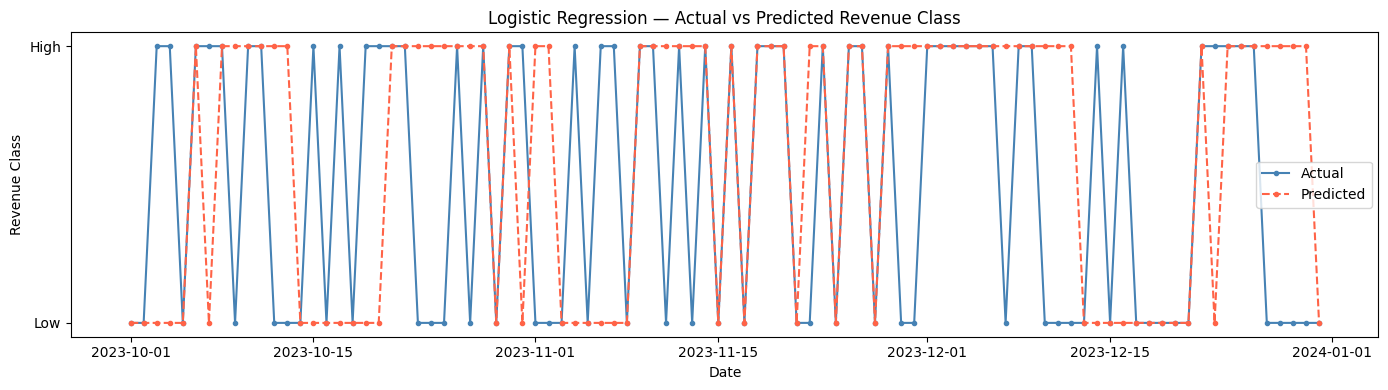

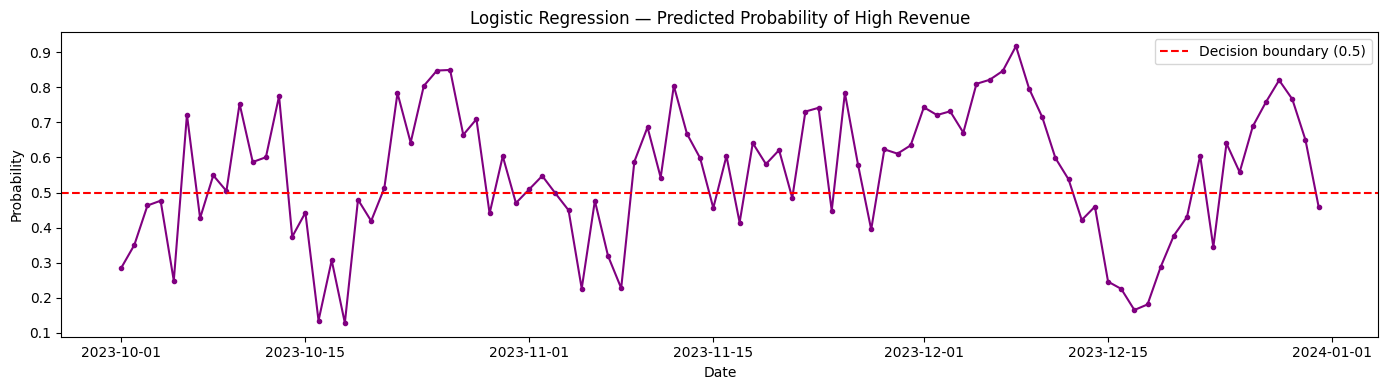

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Aggregation of transaction spent daily 

df = pd.read_csv('cafe.csv')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

daily = df.groupby(['Transaction Date', 'day_of_week', 'month', 'quarter', 'is_weekend'])['Total Spent'].sum().reset_index()
daily = daily.sort_values('Transaction Date').reset_index(drop=True)

# Creating lag features to inject temporal memory 

daily['revenue_lag_1']     = daily['Total Spent'].shift(1)
daily['revenue_lag_7']     = daily['Total Spent'].shift(7)
daily['revenue_rolling_7'] = daily['Total Spent'].rolling(7).mean()
daily = daily.dropna().reset_index(drop=True)

# Create the target variable and binary values 

median_revenue = daily['Total Spent'].median()
daily['revenue_class'] = (daily['Total Spent'] > median_revenue).astype(int)
print(f"Median daily revenue: £{median_revenue:.2f}")
print(f"Class distribution:\n{daily['revenue_class'].value_counts()}")

# Split into train and test periods to train the model 

train = daily[daily['Transaction Date'] < '2023-10-01']
test  = daily[daily['Transaction Date'] >= '2023-10-01']

features = ['day_of_week', 'month', 'quarter', 'is_weekend',
            'revenue_lag_1', 'revenue_lag_7', 'revenue_rolling_7']

X_train, y_train = train[features], train['revenue_class']
X_test,  y_test  = test[features],  test['revenue_class']

# Ensure fair coefficient estimation 

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Model training
model = LogisticRegression(random_state=42)
model.fit(X_train_s, y_train)

# Predictions
pred = model.predict(X_test_s)
prob = model.predict_proba(X_test_s)[:, 1]  # probability of high revenue

# Calculate model accuracy 

print(f"\nAccuracy: {accuracy_score(y_test, pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, pred,
      target_names=['Low revenue', 'High revenue']))

# Create confusion matrix
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low revenue', 'High revenue'])
disp.plot(colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot actual vs predicted over time, success rate
plt.figure(figsize=(14, 4))
plt.plot(test['Transaction Date'].values, y_test.values,
         label='Actual', color='steelblue', marker='o', markersize=3)
plt.plot(test['Transaction Date'].values, pred,
         label='Predicted', color='tomato', linestyle='--', marker='o', markersize=3)
plt.yticks([0, 1], ['Low', 'High'])
plt.title('Logistic Regression — Actual vs Predicted Revenue Class')
plt.xlabel('Date')
plt.ylabel('Revenue Class')
plt.legend()
plt.tight_layout()
plt.show()

# Step 11 - Plot predicted probability over time
plt.figure(figsize=(14, 4))
plt.plot(test['Transaction Date'].values, prob,
         color='purple', marker='o', markersize=3)
plt.axhline(y=0.5, color='red', linestyle='--', label='Decision boundary (0.5)')
plt.title('Logistic Regression — Predicted Probability of High Revenue')
plt.xlabel('Date')
plt.ylabel('Probability')
plt.legend()
plt.tight_layout()
plt.show()

## Logistic regression with more features 

Compared to the previous model, we added more lag features for the model to have more signals on expected revenue. In this case, incorporating lag features, rolling averages, volatility measures, and seasonal indicators allows the model to learn temporal dependencies, trends, and recurring behaviors in daily revenue. These features enrich the input space, enabling Logistic Regression to approximate more complex relationships even though it is a linear model. As a result, the model becomes more accurate because it can distinguish between high- and low-revenue days using both recent history and calendar-based patterns.

However, increasing the number of features also introduces potential drawbacks. First, there is a risk of overfitting, where the model becomes too tailored to the training data and may not generalize well to new or unseen data. Second, some engineered features (such as lagged revenue and rolling averages) are highly correlated with the target variable, which can make the task artificially easier and lead to overly optimistic performance metrics. Third, adding many features increases model complexity and can introduce multicollinearity, where features provide overlapping information and reduce interpretability. Therefore, while adding more features can significantly improve predictive performance, it should be done carefully with proper validation to ensure that the improvements reflect genuine generalization rather than information redundancy or indirect leakage.

Median daily revenue: £230.50
Class distribution:
revenue_class
0    168
1    167
Name: count, dtype: int64

Accuracy: 0.957

Classification Report:
              precision    recall  f1-score   support

 Low revenue       1.00      0.91      0.95        45
High revenue       0.92      1.00      0.96        47

    accuracy                           0.96        92
   macro avg       0.96      0.96      0.96        92
weighted avg       0.96      0.96      0.96        92



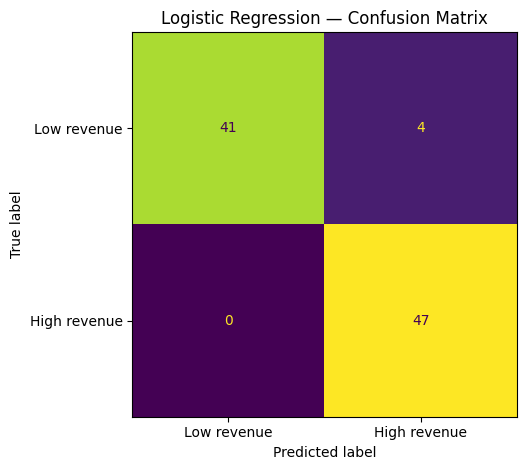

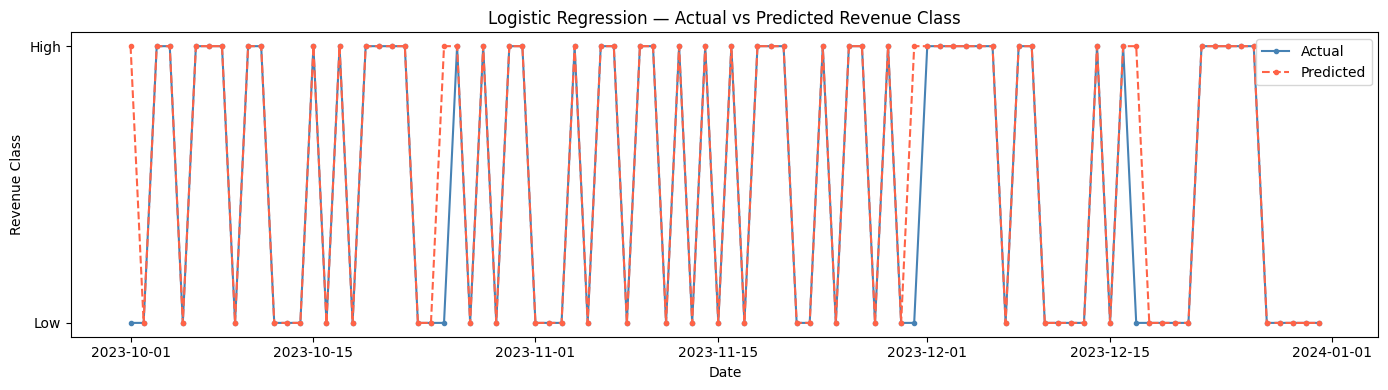

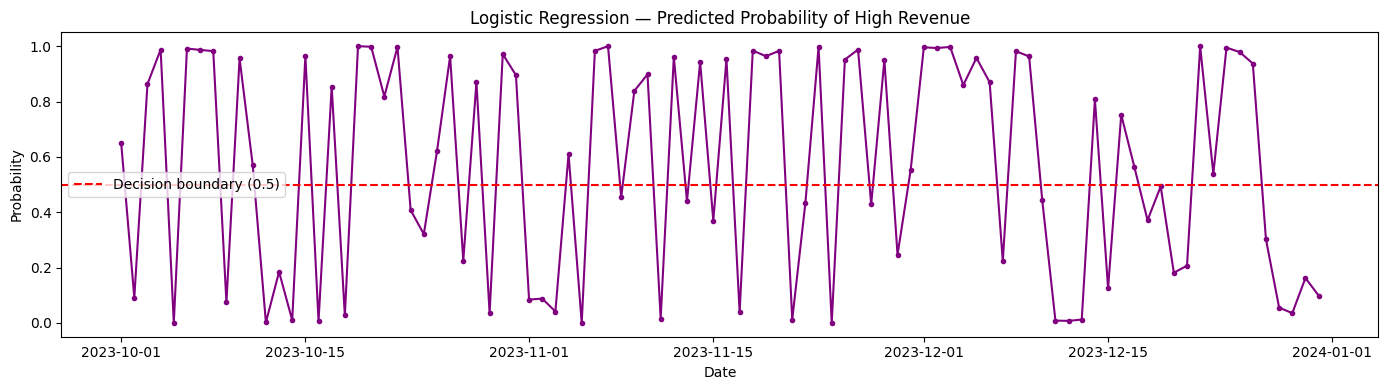

In [ ]:
# SAME MODEL MORE FEATURES 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Grouping by total spent daily 
df = pd.read_csv('cafe.csv')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

daily = df.groupby(['Transaction Date', 'day_of_week', 'month', 'quarter', 'is_weekend'])['Total Spent'].sum().reset_index()
daily = daily.sort_values('Transaction Date').reset_index(drop=True)

# New lag features 
daily['revenue_lag_1']      = daily['Total Spent'].shift(1)
daily['revenue_lag_7']      = daily['Total Spent'].shift(7)
daily['revenue_lag_14']     = daily['Total Spent'].shift(14)   # 2 week lag
daily['revenue_lag_30']     = daily['Total Spent'].shift(30)   # monthly lag

# Detecting trends over time 
daily['revenue_rolling_7']  = daily['Total Spent'].rolling(7).mean()
daily['revenue_rolling_14'] = daily['Total Spent'].rolling(14).mean()  # 2 week trend
daily['revenue_rolling_30'] = daily['Total Spent'].rolling(30).mean()  # monthly trend

# Predicts volatility and direction of change 

daily['revenue_std_7']      = daily['Total Spent'].rolling(7).std()    # how unstable revenue is
daily['revenue_std_14']     = daily['Total Spent'].rolling(14).std()   # 2 week volatility
daily['revenue_momentum']   = daily['Total Spent'].diff(7)             # change vs 7 days ago
daily['revenue_pct_change'] = daily['Total Spent'].pct_change(7)       # % change vs 7 days ago

# Day of the week feature create binary 
daily['is_monday']          = (daily['day_of_week'] == 0).astype(int)
daily['is_friday']          = (daily['day_of_week'] == 4).astype(int)
daily['is_saturday']        = (daily['day_of_week'] == 5).astype(int)
daily['is_sunday']          = (daily['day_of_week'] == 6).astype(int)

# SSeasonality features
daily['is_december']        = (daily['month'] == 12).astype(int)  # Christmas season
daily['is_summer']          = (daily['month'].isin([6, 7, 8])).astype(int)

daily = daily.dropna().reset_index(drop=True)

# Use the median to determine revenue class (higer, or lower than median)
median_revenue = daily['Total Spent'].median()
daily['revenue_class'] = (daily['Total Spent'] > median_revenue).astype(int)
print(f"Median daily revenue: £{median_revenue:.2f}")
print(f"Class distribution:\n{daily['revenue_class'].value_counts()}")

# Train and test split 
train = daily[daily['Transaction Date'] < '2023-10-01']
test  = daily[daily['Transaction Date'] >= '2023-10-01']

features = [
    # Original features
    'day_of_week', 'month', 'quarter', 'is_weekend',
    # Lag features
    'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_14', 'revenue_lag_30',
    # Rolling averages
    'revenue_rolling_7', 'revenue_rolling_14', 'revenue_rolling_30',
    # Volatility and momentum
    'revenue_std_7', 'revenue_std_14', 'revenue_momentum', 'revenue_pct_change',
    # Day flags
    'is_monday', 'is_friday', 'is_saturday', 'is_sunday',
    # Season flags
    'is_december', 'is_summer'
]

X_train, y_train = train[features], train['revenue_class']
X_test,  y_test  = test[features],  test['revenue_class']

# Coefficient scaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_s, y_train)

# Predictions
pred = model.predict(X_test_s)
prob = model.predict_proba(X_test_s)[:, 1]

# Evaluation 
print(f"\nAccuracy: {accuracy_score(y_test, pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, pred,
      target_names=['Low revenue', 'High revenue']))

# Confusion Matrix 
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low revenue', 'High revenue'])
disp.plot(colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot actual vs predicted over time
plt.figure(figsize=(14, 4))
plt.plot(test['Transaction Date'].values, y_test.values,
         label='Actual', color='steelblue', marker='o', markersize=3)
plt.plot(test['Transaction Date'].values, pred,
         label='Predicted', color='tomato', linestyle='--', marker='o', markersize=3)
plt.yticks([0, 1], ['Low', 'High'])
plt.title('Logistic Regression — Actual vs Predicted Revenue Class')
plt.xlabel('Date')
plt.ylabel('Revenue Class')
plt.legend()
plt.tight_layout()
plt.show()

# Plot predicted probability over time
plt.figure(figsize=(14, 4))
plt.plot(test['Transaction Date'].values, prob,
         color='purple', marker='o', markersize=3)
plt.axhline(y=0.5, color='red', linestyle='--', label='Decision boundary (0.5)')
plt.title('Logistic Regression — Predicted Probability of High Revenue')
plt.xlabel('Date')
plt.ylabel('Probability')
plt.legend()
plt.tight_layout()
plt.show()

In [142]:
# Create a comparison dataframe
comparison = pd.DataFrame({
    'Date':      test['Transaction Date'].values,
    'Actual':    y_test.values,
    'Predicted': pred,
    'Correct':   (y_test.values == pred)
})

# Show only wrong predictions
print("Wrong predictions:")
print(comparison[comparison['Correct'] == False])

# Show summary
correct   = comparison['Correct'].sum()
incorrect = len(comparison) - correct
print(f"\nCorrect:   {correct} days")
print(f"Incorrect: {incorrect} days")
print(f"Accuracy:  {correct/len(comparison)*100:.1f}%")

Wrong predictions:
         Date  Actual  Predicted  Correct
0  2023-10-01       0          1    False
24 2023-10-25       0          1    False
60 2023-11-30       0          1    False
77 2023-12-17       0          1    False

Correct:   88 days
Incorrect: 4 days
Accuracy:  95.7%


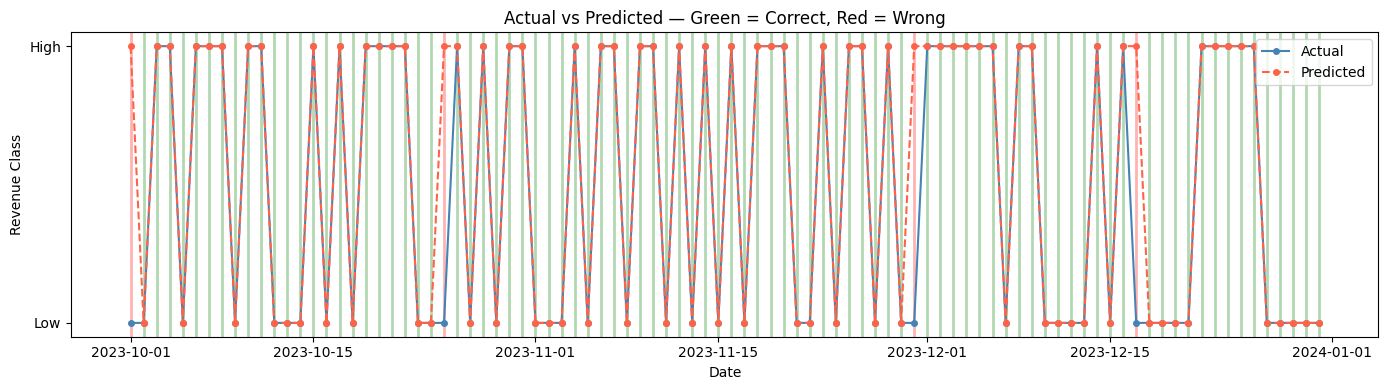

In [143]:
plt.figure(figsize=(14, 4))

for i, row in comparison.iterrows():
    color = 'green' if row['Correct'] else 'red'
    plt.axvline(x=row['Date'], color=color, alpha=0.3, linewidth=2)

plt.plot(test['Transaction Date'].values, y_test.values,
         label='Actual', color='steelblue', marker='o', markersize=4, zorder=5)
plt.plot(test['Transaction Date'].values, pred,
         label='Predicted', color='tomato', linestyle='--', marker='o', markersize=4, zorder=5)

plt.yticks([0, 1], ['Low', 'High'])
plt.title('Actual vs Predicted — Green = Correct, Red = Wrong')
plt.xlabel('Date')
plt.ylabel('Revenue Class')
plt.legend()
plt.tight_layout()
plt.show()

## Decision tree model 

The decision tree model achieved a training accuracy of 68.8% and a test accuracy of 64.1%, indicating a moderate level of predictive performance with a relatively small gap between training and testing results. This suggests that the model generalizes reasonably well and is not severely overfitting the training data.

Feature importance analysis shows that the model relies primarily on lagged and rolling revenue features (especially revenue_rolling_7 and revenue_lag_1), while calendar-based features such as day of the week, month, and weekend indicators have little to no influence. This indicates that the model is largely driven by short-term revenue trends rather than broader temporal or seasonal effects. To improve performance, further feature engineering could be explored, such as incorporating additional lag periods

Train accuracy: 68.8%
Test accuracy:  64.1%

Accuracy: 0.641

Classification Report:
              precision    recall  f1-score   support

 Low revenue       0.66      0.56      0.60        45
High revenue       0.63      0.72      0.67        47

    accuracy                           0.64        92
   macro avg       0.64      0.64      0.64        92
weighted avg       0.64      0.64      0.64        92



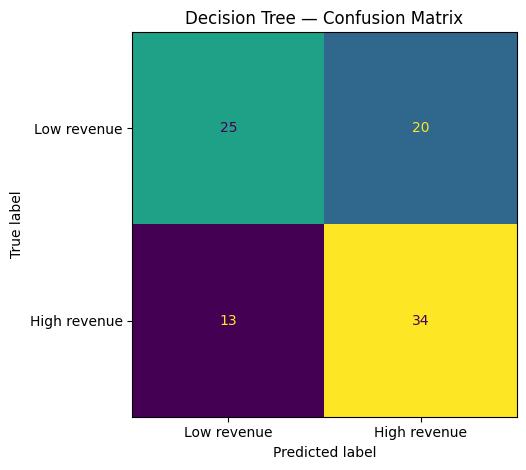

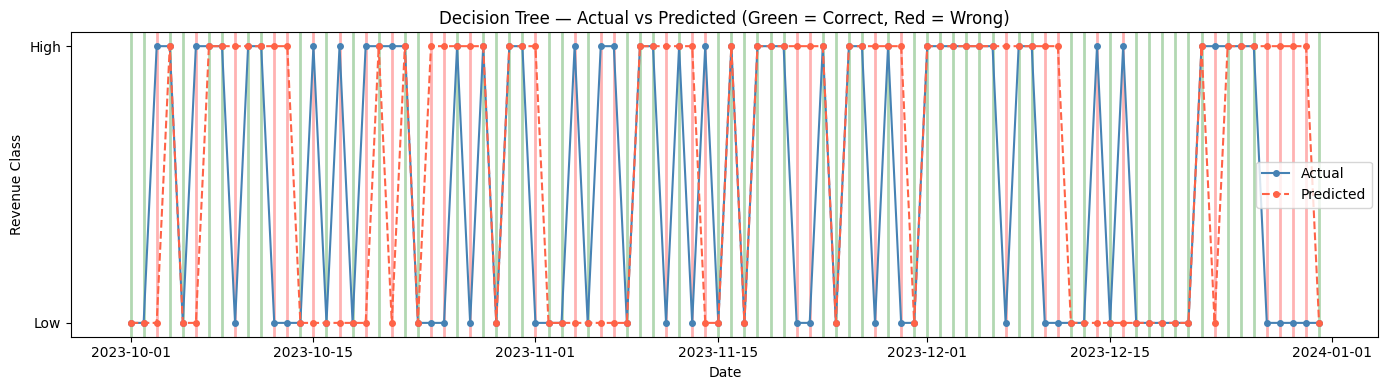

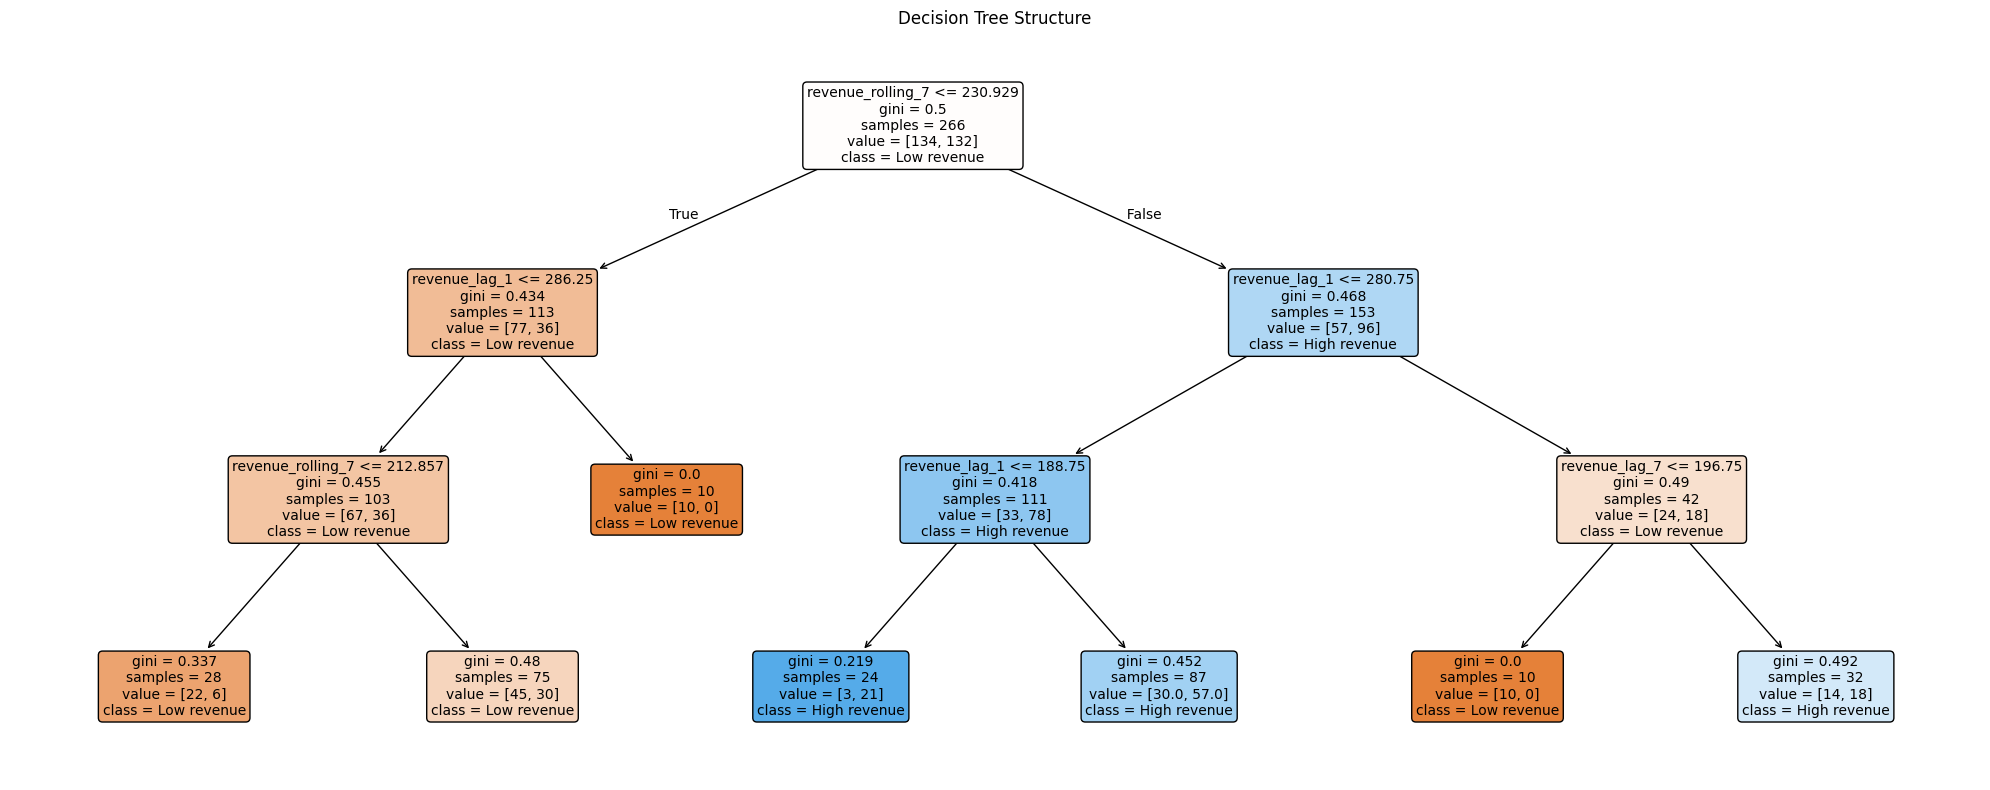

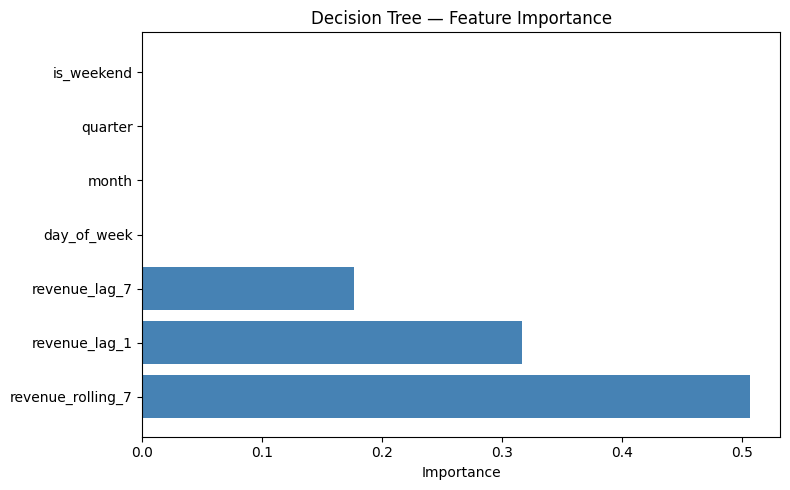

             Feature  Importance
6  revenue_rolling_7    0.506631
4      revenue_lag_1    0.316459
5      revenue_lag_7    0.176910
0        day_of_week    0.000000
1              month    0.000000
2            quarter    0.000000
3         is_weekend    0.000000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Prepare data and group into daily totals 
df = pd.read_csv('cafe.csv')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

daily = df.groupby(['Transaction Date', 'day_of_week', 'month', 'quarter', 'is_weekend'])['Total Spent'].sum().reset_index()
daily = daily.sort_values('Transaction Date').reset_index(drop=True)

# Create lag features
daily['revenue_lag_1']     = daily['Total Spent'].shift(1)
daily['revenue_lag_7']     = daily['Total Spent'].shift(7)
daily['revenue_rolling_7'] = daily['Total Spent'].rolling(7).mean()
daily = daily.dropna().reset_index(drop=True)

# Create target variable finding median revenue
median_revenue = daily['Total Spent'].median()
daily['revenue_class'] = (daily['Total Spent'] > median_revenue).astype(int)

# Split into train and test
train = daily[daily['Transaction Date'] < '2023-10-01']
test  = daily[daily['Transaction Date'] >= '2023-10-01']

features = ['day_of_week', 'month', 'quarter', 'is_weekend',
            'revenue_lag_1', 'revenue_lag_7', 'revenue_rolling_7']

X_train, y_train = train[features], train['revenue_class']
X_test,  y_test  = test[features],  test['revenue_class']

# Train
model = DecisionTreeClassifier(
    max_depth=3,           # keep tree shallow
    min_samples_split=10,  # need 10 samples to split
    min_samples_leaf=5,    # each leaf needs 5 samples
    random_state=42
)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Check overfitting
train_pred = model.predict(X_train)
print(f"Train accuracy: {accuracy_score(y_train, train_pred)*100:.1f}%")
print(f"Test accuracy:  {accuracy_score(y_test, pred)*100:.1f}%")

# Evaluate
print(f"\nAccuracy: {accuracy_score(y_test, pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, pred,
      target_names=['Low revenue', 'High revenue']))

# Confusion matrix
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low revenue', 'High revenue'])
disp.plot(colorbar=False)
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

#  Actual vs predicted plot
comparison = pd.DataFrame({
    'Date':      test['Transaction Date'].values,
    'Actual':    y_test.values,
    'Predicted': pred,
    'Correct':   (y_test.values == pred)
})

plt.figure(figsize=(14, 4))
for i, row in comparison.iterrows():
    color = 'green' if row['Correct'] else 'red'
    plt.axvline(x=row['Date'], color=color, alpha=0.3, linewidth=2)

plt.plot(test['Transaction Date'].values, y_test.values,
         label='Actual', color='steelblue', marker='o', markersize=4, zorder=5)
plt.plot(test['Transaction Date'].values, pred,
         label='Predicted', color='tomato', linestyle='--', marker='o', markersize=4, zorder=5)
plt.yticks([0, 1], ['Low', 'High'])
plt.title('Decision Tree — Actual vs Predicted (Green = Correct, Red = Wrong)')
plt.xlabel('Date')
plt.ylabel('Revenue Class')
plt.legend()
plt.tight_layout()
plt.show()

# Visualise the tree
plot_tree(model,
          feature_names=features,
          class_names=['Low revenue', 'High revenue'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure')
plt.tight_layout()
plt.show()

# Feature importance
importance = pd.DataFrame({
    'Feature':    features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.title('Decision Tree — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importance)

## Trying logistic regression with cross validation

Logistic Regression — Cross Validation Results:
  Fold 1: 50.8%
  Fold 2: 61.0%
  Fold 3: 66.1%
  Fold 4: 52.5%
  Fold 5: 67.8%

  Mean accuracy:  59.7%
  Std deviation:  6.9%


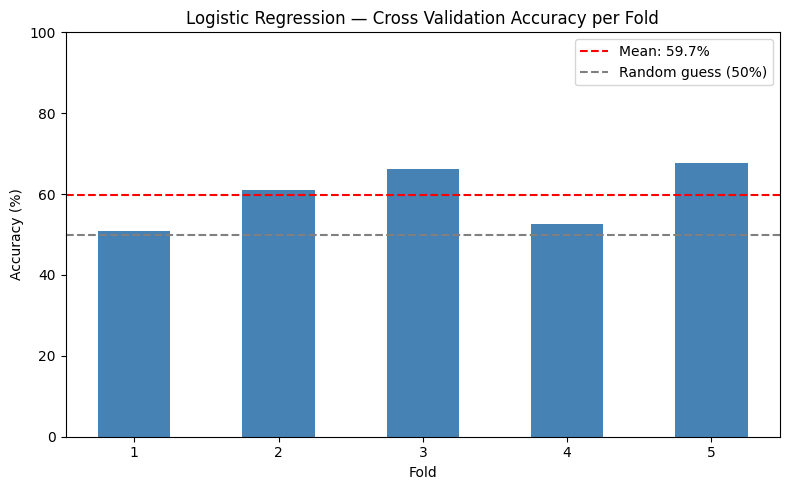

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Step 1 - Prepare the data
df = pd.read_csv('cafe.csv')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

daily = df.groupby(['Transaction Date', 'day_of_week', 'month', 'quarter', 'is_weekend'])['Total Spent'].sum().reset_index()
daily = daily.sort_values('Transaction Date').reset_index(drop=True)

# Step 2 - Create lag features
daily['revenue_lag_1']     = daily['Total Spent'].shift(1)
daily['revenue_lag_7']     = daily['Total Spent'].shift(7)
daily['revenue_rolling_7'] = daily['Total Spent'].rolling(7).mean()
daily = daily.dropna().reset_index(drop=True)

# Step 3 - Create target variable
median_revenue = daily['Total Spent'].median()
daily['revenue_class'] = (daily['Total Spent'] > median_revenue).astype(int)

# Step 4 - Define X and y
features = ['day_of_week', 'month', 'quarter', 'is_weekend',
            'revenue_lag_1', 'revenue_lag_7', 'revenue_rolling_7']

X = daily[features]
y = daily['revenue_class']

# Step 5 - Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6 - Cross validation
tscv = TimeSeriesSplit(n_splits=5)
model = LogisticRegression(random_state=42)
scores = cross_val_score(model, X_scaled, y, cv=tscv, scoring='accuracy')

# Step 7 - Results
print("Logistic Regression — Cross Validation Results:")
print(f"  Fold 1: {scores[0]*100:.1f}%")
print(f"  Fold 2: {scores[1]*100:.1f}%")
print(f"  Fold 3: {scores[2]*100:.1f}%")
print(f"  Fold 4: {scores[3]*100:.1f}%")
print(f"  Fold 5: {scores[4]*100:.1f}%")
print(f"\n  Mean accuracy:  {scores.mean()*100:.1f}%")
print(f"  Std deviation:  {scores.std()*100:.1f}%")

# Step 8 - Plot fold scores
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), scores * 100, color='steelblue', width=0.5)
plt.axhline(y=scores.mean()*100, color='red', linestyle='--',
            label=f'Mean: {scores.mean()*100:.1f}%')
plt.axhline(y=50, color='gray', linestyle='--', label='Random guess (50%)')
plt.title('Logistic Regression — Cross Validation Accuracy per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()